# Task 2A: Travel Behaviour Analysis

Weighted behavioural analysis using the Task 1 analysis-ready dataset.

## 1. Load Task 1 output

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_file =  root / "output" / "task1_analysis_ready_trips.csv"
if data_file is None:
    raise FileNotFoundError("Run Task 1 first.")

df = pd.read_csv(data_file)
print(f"Trips: {len(df):,} | Respondents: {df['caseid'].nunique():,}")

Trips: 6,631 | Respondents: 4,097


## 2. Mode groups

In [2]:
MODE_GROUP = {
    "Car/ van (as the driver)": "Car / van",
    "Car/ van (as a passenger)": "Car / van",
    "Walking": "Active / wheeling",
    "Pedal cycle": "Active / wheeling",
    "Electric cycle (e-bike)": "Active / wheeling",
    "Mobility scooter": "Active / wheeling",
    "Hire e-bike/ e-scooter": "Micromobility",
    "Rail": "Public transport",
    "Public bus service": "Public transport",
    "Other coach (e.g. long distance coaches)": "Public transport",
    "Ferry": "Public transport",
    "Private bus/ coach (e.g. school service, other private service)": "Private bus / coach",
    "Taxi/ minicab": "Taxi / private hire",
    "Motorcycle/ moped": "Motorcycle / moped",
    "Something else": "Other / unspecified",
}

df["mode_group"] = df["Main mode"].map(MODE_GROUP)
print("Unmapped modes:", df.loc[df["Main mode"].notna() & df["mode_group"].isna(), "Main mode"].unique().tolist())

Unmapped modes: []


**Assumption:** All source modes are retained. Grouping is used only for readable comparisons.

In [3]:
def weighted_share(data, group):
    s = data.groupby(group, observed=False)["Weight_2"].sum()
    return (s / s.sum() * 100).sort_values(ascending=False)

def weighted_quantile(values, weights, q=(0.25, 0.50, 0.75)):
    x = pd.DataFrame({"v": values, "w": weights}).dropna()
    x = x[x["w"] > 0].sort_values("v")
    c = x["w"].cumsum() / x["w"].sum()
    return np.interp(q, c, x["v"])

def row_pct(data, index, columns):
    x = data.pivot_table(index=index, columns=columns, values="Weight_2",
                         aggfunc="sum", fill_value=0, observed=False)
    return x.div(x.sum(axis=1), axis=0) * 100

## 3. Mode share

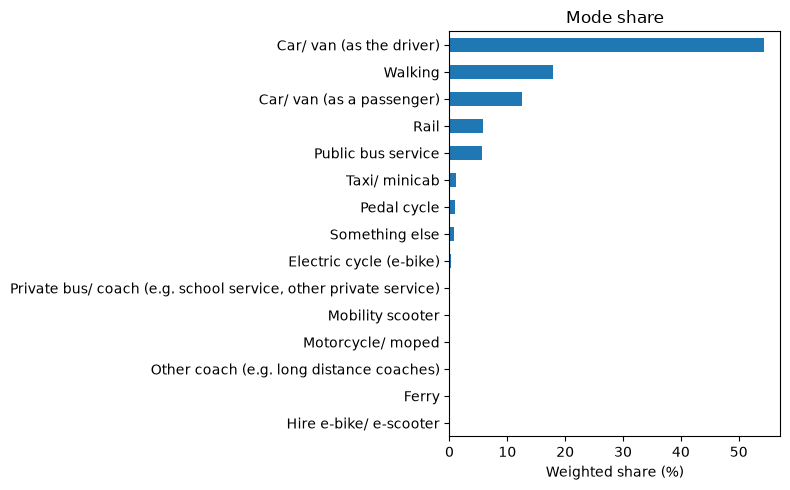

In [4]:
mode_detail = weighted_share(df[df["Main mode"].notna()], "Main mode")
mode_detail.sort_values().plot.barh(figsize=(8, 5))
plt.xlabel("Weighted share (%)")
plt.ylabel("")
plt.title("Mode share")
plt.tight_layout()
plt.show()

**Interpretation:** Car/van dominates the sample. Driver and passenger journeys are examined separately.

## 4. Trip purpose

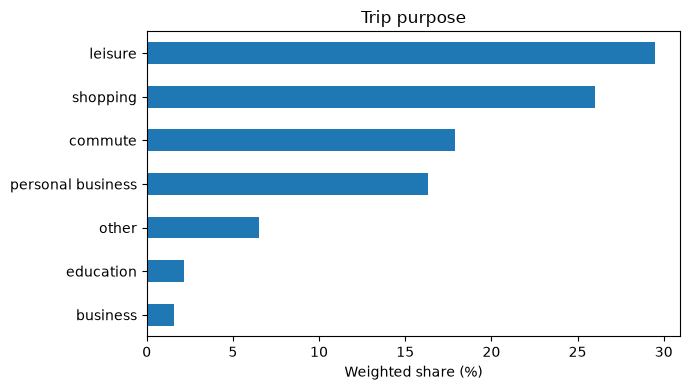

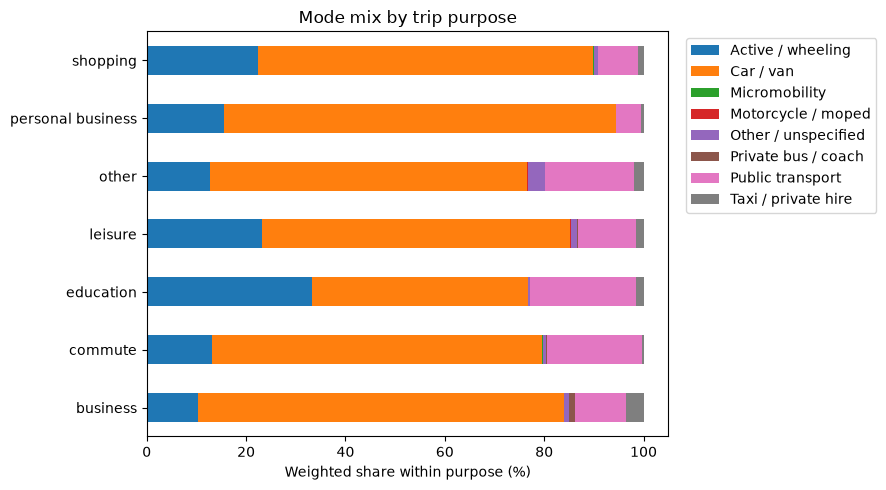

In [5]:
purpose = weighted_share(df[df["Purpose_category"].notna()], "Purpose_category")
purpose.sort_values().plot.barh(figsize=(7, 4))
plt.xlabel("Weighted share (%)")
plt.ylabel("")
plt.title("Trip purpose")
plt.tight_layout()
plt.show()

purpose_mode = row_pct(
    df.dropna(subset=["Purpose_category", "mode_group"]),
    "Purpose_category", "mode_group"
)
purpose_mode.plot.barh(stacked=True, figsize=(9, 5))
plt.xlabel("Weighted share within purpose (%)")
plt.ylabel("")
plt.title("Mode mix by trip purpose")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** Purpose separates different travel markets behind the headline mode share.

## 5. Observed trip frequency

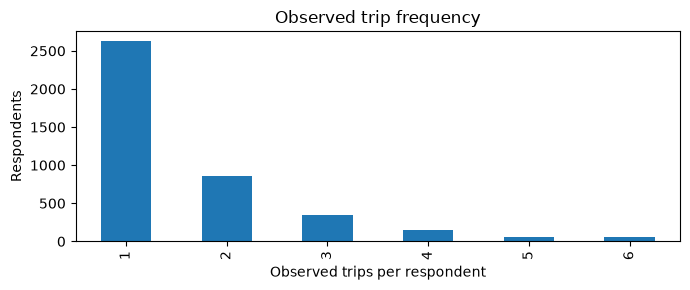

In [6]:
trip_frequency = df.groupby("caseid").size().value_counts().sort_index()
trip_frequency.plot.bar(figsize=(7, 3))
plt.xlabel("Observed trips per respondent")
plt.ylabel("Respondents")
plt.title("Observed trip frequency")
plt.tight_layout()
plt.show()

**Assumption:** This describes the supplied extract, not a population daily trip rate because zero-trip respondents are unavailable.

## 6. Distance travelled

Valid trips: 5,624 | Weighted median: 6.2 km | IQR: 2.3-20.1 km


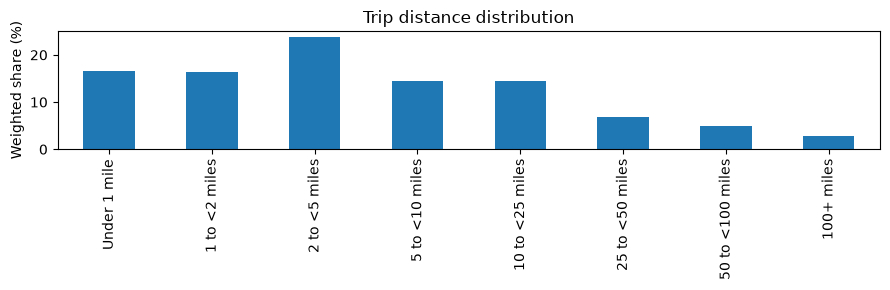

In [7]:
distance = df[df["distance_analysis_valid"].astype(str).str.lower().eq("true")].copy()
distance["Distance category"] = pd.to_numeric(distance["Distance category"], errors="coerce")

DISTANCE_LABELS = {
    1: "Under 1 mile", 2: "1 to <2 miles", 3: "2 to <5 miles", 4: "5 to <10 miles",
    5: "10 to <25 miles", 6: "25 to <50 miles", 7: "50 to <100 miles", 8: "100+ miles"
}
DISTANCE_ORDER = list(DISTANCE_LABELS.values())
distance["distance_band"] = distance["Distance category"].map(DISTANCE_LABELS)

q1, med, q3 = weighted_quantile(distance["Distance (km)"], distance["Weight_2"])
print(f"Valid trips: {len(distance):,} | Weighted median: {med:.1f} km | IQR: {q1:.1f}-{q3:.1f} km")

distance_share = weighted_share(distance.dropna(subset=["distance_band"]), "distance_band").reindex(DISTANCE_ORDER)
distance_share.plot.bar(figsize=(9, 3))
plt.ylabel("Weighted share (%)")
plt.xlabel("")
plt.title("Trip distance distribution")
plt.tight_layout()
plt.show()

## 7. Mode mix by distance

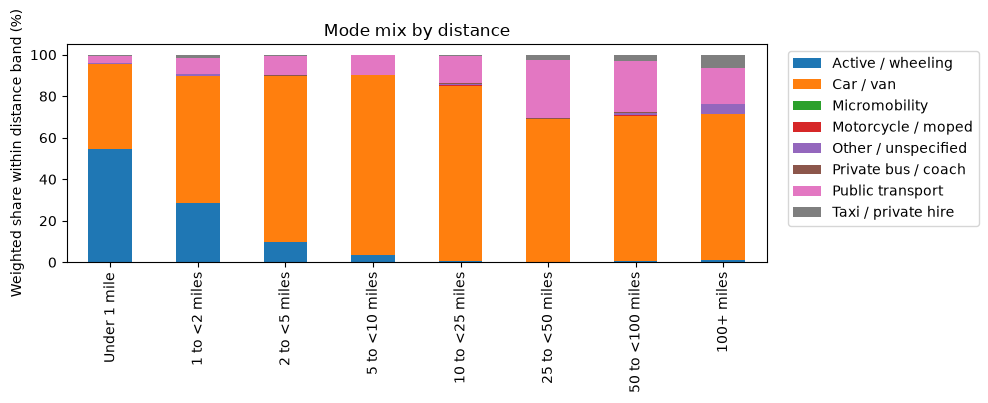

In [8]:
mode_distance = row_pct(
    distance.dropna(subset=["distance_band", "mode_group"]),
    "distance_band", "mode_group"
).reindex(DISTANCE_ORDER)

mode_distance.plot.bar(stacked=True, figsize=(10, 4))
plt.ylabel("Weighted share within distance band (%)")
plt.xlabel("")
plt.title("Mode mix by distance")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** Distance changes the modal mix substantially. Short-distance car use and mid-distance public transport are examined separately.

## 8. Distance by purpose

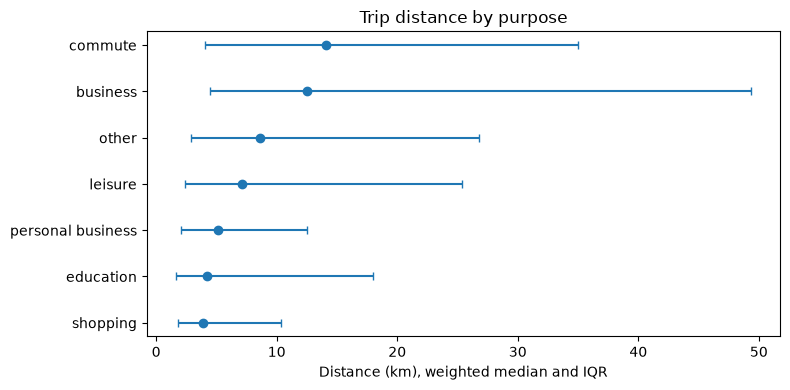

In [9]:
rows = []
for name, g in distance.dropna(subset=["Purpose_category"]).groupby("Purpose_category"):
    q1, med, q3 = weighted_quantile(g["Distance (km)"], g["Weight_2"])
    rows.append([name, q1, med, q3])

purpose_distance = pd.DataFrame(rows, columns=["Purpose", "Q1", "Median", "Q3"]).sort_values("Median")
xerr = np.vstack([
    purpose_distance["Median"] - purpose_distance["Q1"],
    purpose_distance["Q3"] - purpose_distance["Median"]
])

plt.figure(figsize=(8, 4))
plt.errorbar(purpose_distance["Median"], purpose_distance["Purpose"], xerr=xerr, fmt="o", capsize=3)
plt.xlabel("Distance (km), weighted median and IQR")
plt.ylabel("")
plt.title("Trip distance by purpose")
plt.tight_layout()
plt.show()

## 9. Travel time

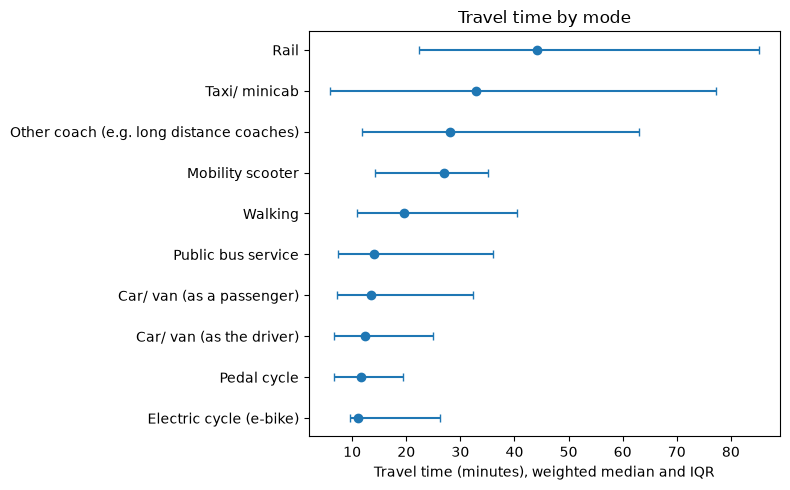

In [10]:
time_valid = df[pd.to_numeric(df["Travel Time (minutes)"], errors="coerce").gt(0)].copy()

rows = []
for name, g in time_valid.groupby("Main mode"):
    q1, med, q3 = weighted_quantile(g["Travel Time (minutes)"], g["Weight_2"])
    rows.append([name, q1, med, q3])

time_mode = pd.DataFrame(rows, columns=["Mode", "Q1", "Median", "Q3"]).sort_values("Median")
xerr = np.vstack([time_mode["Median"] - time_mode["Q1"],
                  time_mode["Q3"] - time_mode["Median"]])

plt.figure(figsize=(8, 5))
plt.errorbar(time_mode["Median"], time_mode["Mode"], xerr=xerr, fmt="o", capsize=3)
plt.xlabel("Travel time (minutes), weighted median and IQR")
plt.ylabel("")
plt.title("Travel time by mode")
plt.tight_layout()
plt.show()

**Assumption:** Travel time is descriptive only because Task 1 identified provenance concerns for some modes.

## 10. Time of day

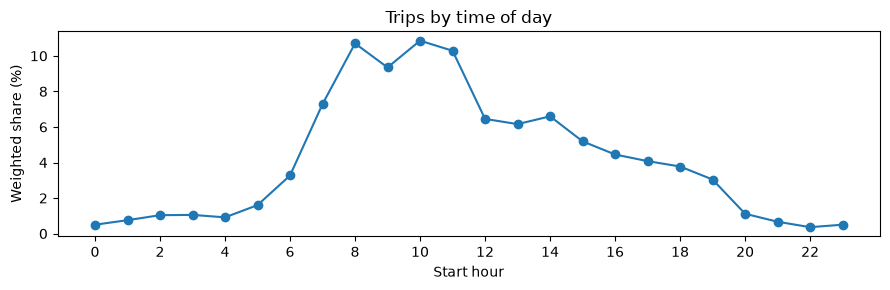

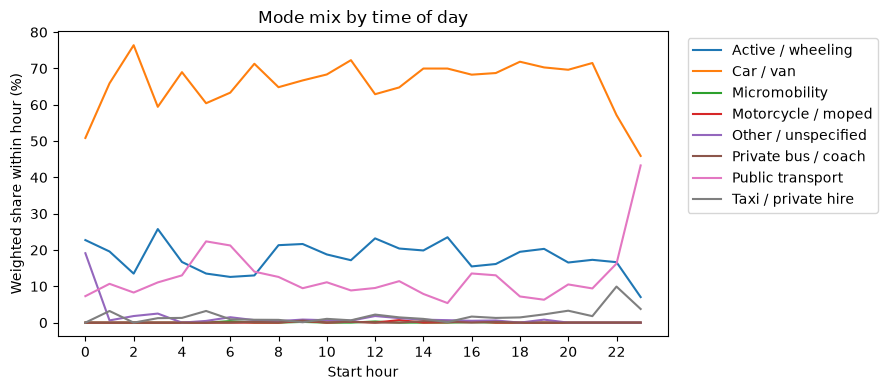

In [11]:
hour = pd.to_numeric(df["Start time - first hour"], errors="coerce")
time_df = df[hour.between(0, 23)].copy()
time_df["hour"] = hour[hour.between(0, 23)].astype(int)

hour_share = weighted_share(time_df, "hour").sort_index()
hour_share.plot.line(marker="o", figsize=(9, 3))
plt.xlabel("Start hour")
plt.ylabel("Weighted share (%)")
plt.title("Trips by time of day")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

hour_mode = row_pct(time_df.dropna(subset=["mode_group"]), "hour", "mode_group")
hour_mode.plot.line(figsize=(9, 4))
plt.xlabel("Start hour")
plt.ylabel("Weighted share within hour (%)")
plt.title("Mode mix by time of day")
plt.xticks(range(0, 24, 2))
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Day of week

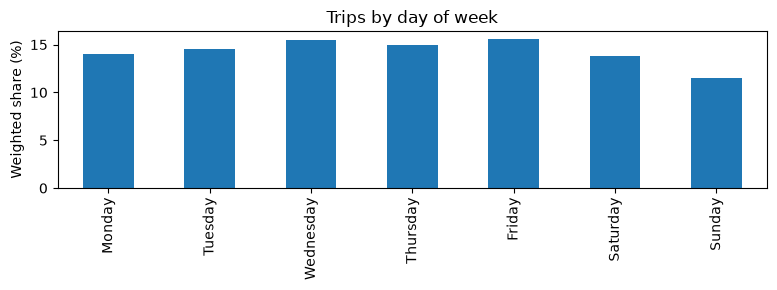

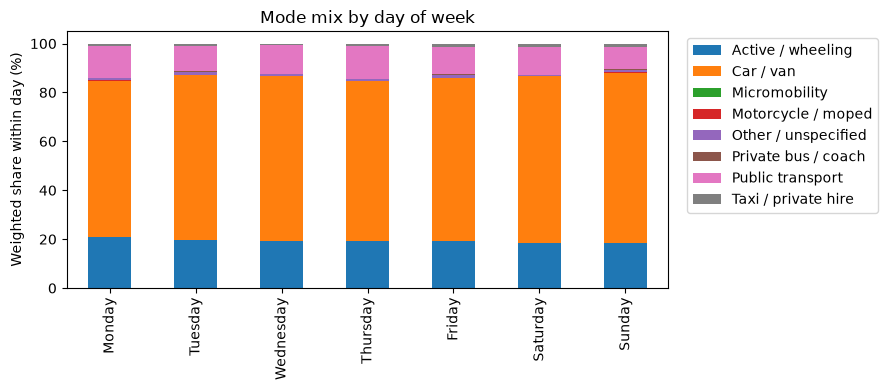

In [12]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_df = df[df["Day of week"].isin(DAY_ORDER)].copy()

day_share = weighted_share(day_df, "Day of week").reindex(DAY_ORDER)
day_share.plot.bar(figsize=(8, 3))
plt.ylabel("Weighted share (%)")
plt.xlabel("")
plt.title("Trips by day of week")
plt.tight_layout()
plt.show()

day_mode = row_pct(day_df.dropna(subset=["mode_group"]), "Day of week", "mode_group").reindex(DAY_ORDER)
day_mode.plot.bar(stacked=True, figsize=(9, 4))
plt.ylabel("Weighted share within day (%)")
plt.xlabel("")
plt.title("Mode mix by day of week")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 12. Demographic availability

In [13]:
terms = ("age", "gender", "sex", "employment", "income", "household", "ethnicity", "disability")
available = [c for c in df.columns if any(t in c.lower() for t in terms)]
print("Demographic fields found:", available)

Demographic fields found: []


**Limitation:** Respondent demographics are not included in the supplied extract.

## 13. Validated trip chains

In [14]:
CHAIN_TOLERANCE_M = 100

seq = df.copy()
seq["_row_id"] = seq.index
seq["trip"] = pd.to_numeric(
    seq["Trip number"].astype("string").str.extract(r"(\d+)", expand=False),
    errors="coerce"
)
seq = seq.sort_values(["caseid", "trip"])

for c in ["trip", "mode_group", "Purpose_category",
          "Origin eastings", "Origin northings",
          "Destination eastings", "Destination northings", "_row_id"]:
    seq[f"next_{c}"] = seq.groupby("caseid")[c].shift(-1)

seq["consecutive"] = seq["next_trip"].eq(seq["trip"] + 1)
seq["od_gap_m"] = np.hypot(
    seq["Destination eastings"] - seq["next_Origin eastings"],
    seq["Destination northings"] - seq["next_Origin northings"]
)
chains = seq[seq["consecutive"] & seq["od_gap_m"].le(CHAIN_TOLERANCE_M)].copy()
chain_rows = set(chains["_row_id"].astype(int)) | set(chains["next__row_id"].dropna().astype(int))

print(f"Validated consecutive pairs: {len(chains):,} | OD tolerance: {CHAIN_TOLERANCE_M} m")

Validated consecutive pairs: 1,091 | OD tolerance: 100 m


**Assumption:** A validated chain requires consecutive trip numbers and destination-to-next-origin continuity within 100 m.

## 14. Car/van deep dive

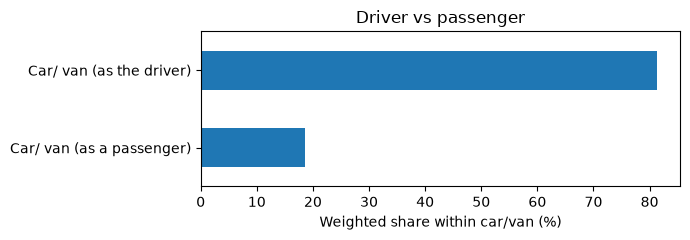

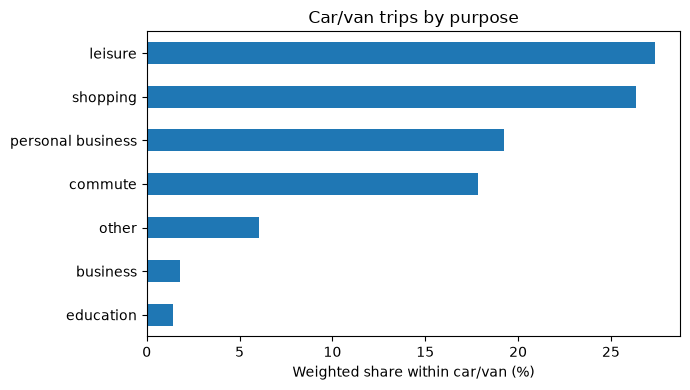

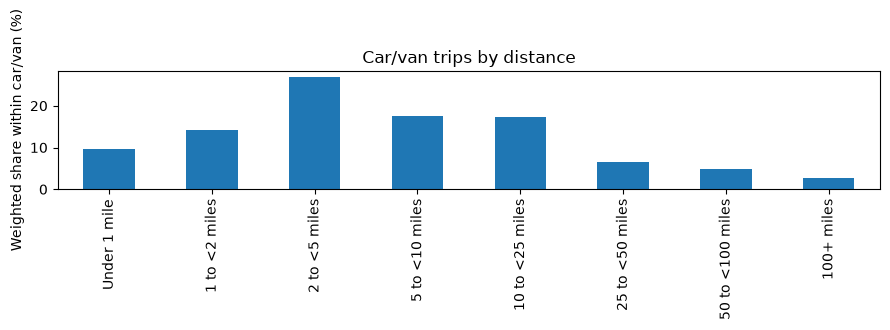

In [15]:
CAR = ["Car/ van (as the driver)", "Car/ van (as a passenger)"]
car = df[df["Main mode"].isin(CAR)].copy()

weighted_share(car, "Main mode").sort_values().plot.barh(figsize=(7, 2.5))
plt.xlabel("Weighted share within car/van (%)")
plt.ylabel("")
plt.title("Driver vs passenger")
plt.tight_layout()
plt.show()

weighted_share(car.dropna(subset=["Purpose_category"]), "Purpose_category").sort_values().plot.barh(figsize=(7, 4))
plt.xlabel("Weighted share within car/van (%)")
plt.ylabel("")
plt.title("Car/van trips by purpose")
plt.tight_layout()
plt.show()

car_dist = distance[distance["Main mode"].isin(CAR)].copy()
weighted_share(car_dist.dropna(subset=["distance_band"]), "distance_band").reindex(DISTANCE_ORDER).plot.bar(figsize=(9, 3))
plt.ylabel("Weighted share within car/van (%)")
plt.xlabel("")
plt.title("Car/van trips by distance")
plt.tight_layout()
plt.show()

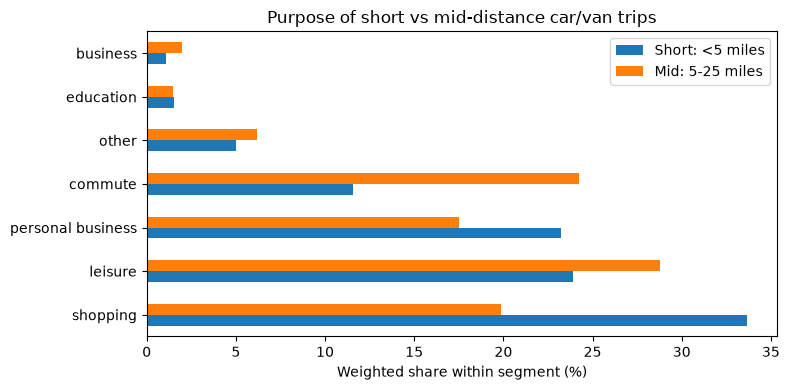

In [16]:
short_car = car_dist[car_dist["Distance category"].isin([1, 2, 3])]
mid_car = car_dist[car_dist["Distance category"].isin([4, 5])]

segment_purpose = pd.concat({
    "Short: <5 miles": weighted_share(short_car, "Purpose_category"),
    "Mid: 5-25 miles": weighted_share(mid_car, "Purpose_category")
}, axis=1).fillna(0)

segment_purpose.plot.barh(figsize=(8, 4))
plt.xlabel("Weighted share within segment (%)")
plt.ylabel("")
plt.title("Purpose of short vs mid-distance car/van trips")
plt.tight_layout()
plt.show()

## 15. Short car trips and trip chaining

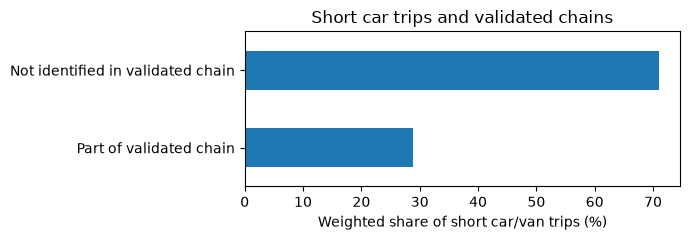

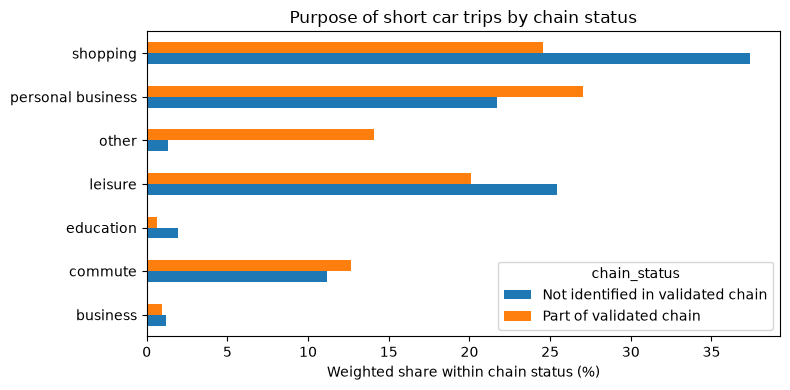

In [17]:
short_chain = short_car.copy()
short_chain["chain_status"] = np.where(
    short_chain.index.isin(chain_rows),
    "Part of validated chain",
    "Not identified in validated chain"
)

chain_share = weighted_share(short_chain, "chain_status")
chain_share.sort_values().plot.barh(figsize=(7, 2.5))
plt.xlabel("Weighted share of short car/van trips (%)")
plt.ylabel("")
plt.title("Short car trips and validated chains")
plt.tight_layout()
plt.show()

chain_purpose = short_chain.pivot_table(
    index="Purpose_category", columns="chain_status",
    values="Weight_2", aggfunc="sum", fill_value=0, observed=False
)
chain_purpose = chain_purpose.div(chain_purpose.sum(axis=0), axis=1) * 100

chain_purpose.plot.barh(figsize=(8, 4))
plt.xlabel("Weighted share within chain status (%)")
plt.ylabel("")
plt.title("Purpose of short car trips by chain status")
plt.tight_layout()
plt.show()

**Interpretation:** Chain membership provides context for short car trips. Trips not validated as part of a chain should not be assumed to be standalone.

## 16. Short-distance active travel

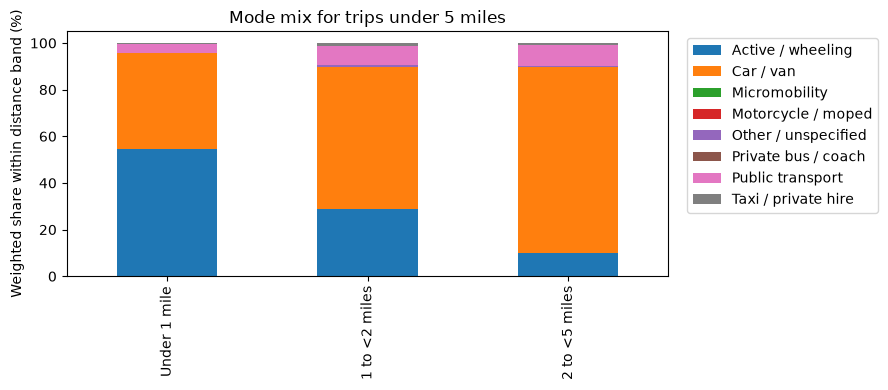

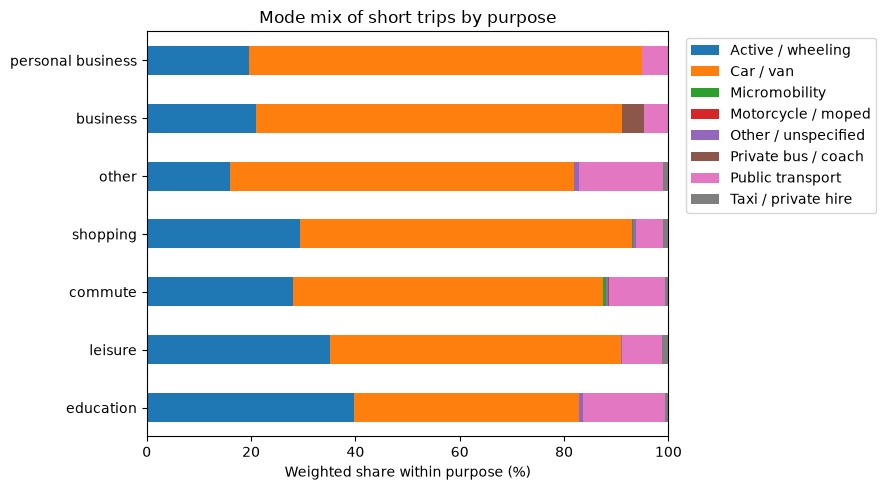

In [18]:
short = distance[distance["Distance category"].isin([1, 2, 3])].copy()

short_mode = row_pct(
    short.dropna(subset=["distance_band", "mode_group"]),
    "distance_band", "mode_group"
).reindex(DISTANCE_ORDER[:3])

short_mode.plot.bar(stacked=True, figsize=(9, 4))
plt.ylabel("Weighted share within distance band (%)")
plt.xlabel("")
plt.title("Mode mix for trips under 5 miles")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

short_purpose_mode = row_pct(
    short.dropna(subset=["Purpose_category", "mode_group"]),
    "Purpose_category", "mode_group"
).sort_values("Car / van")

short_purpose_mode.plot.barh(stacked=True, figsize=(9, 5))
plt.xlabel("Weighted share within purpose (%)")
plt.ylabel("")
plt.title("Mode mix of short trips by purpose")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** Short-distance car use identifies a market for further investigation, not a guaranteed mode-shift opportunity.

## 17. Mid-distance public transport market

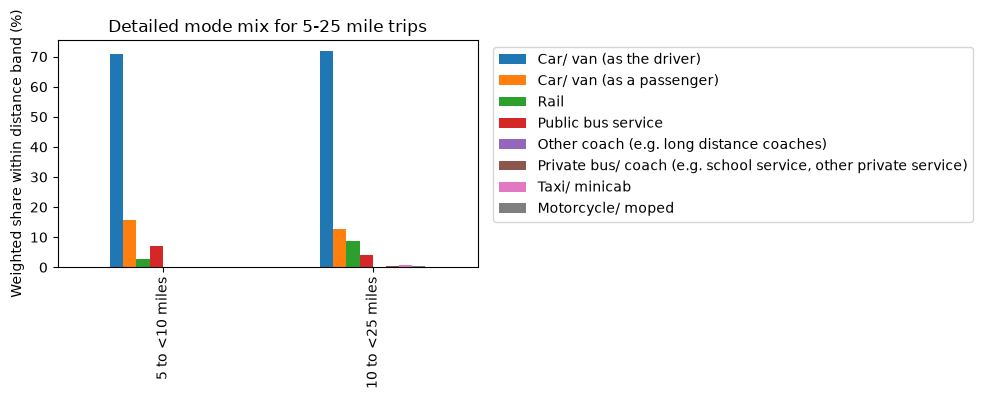

In [19]:
mid = distance[distance["Distance category"].isin([4, 5])].copy()
mid_detail = row_pct(
    mid.dropna(subset=["distance_band", "Main mode"]),
    "distance_band", "Main mode"
).reindex(DISTANCE_ORDER[3:5])

keep = [c for c in [
    "Car/ van (as the driver)", "Car/ van (as a passenger)",
    "Rail", "Public bus service", "Other coach (e.g. long distance coaches)",
    "Private bus/ coach (e.g. school service, other private service)",
    "Taxi/ minicab", "Motorcycle/ moped"
] if c in mid_detail.columns]

mid_detail[keep].plot.bar(figsize=(10, 4))
plt.ylabel("Weighted share within distance band (%)")
plt.xlabel("")
plt.title("Detailed mode mix for 5-25 mile trips")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** This shows where public transport is used in the mid-distance market. Service availability and competitiveness require separate evidence.

## 18. Task 2A close

In [20]:
print("Task 2A complete. Results remain reproducible from this notebook; "
      "separate aggregate CSV exports are not required.")

Task 2A complete. Results remain reproducible from this notebook; separate aggregate CSV exports are not required.
